# Pipeline 


                        RAVDESS dataset
                                ↓
                        EDA (waveform, spectrogram, distribution)
                                ↓
                        Feature extraction
                        (MFCC + chroma + mel + spectral contrast + tonnetz + RMS)
                                ↓
                        Data augmentation
                        (noise + shift + mixed emotion)
                                ↓
                        Soft label generation
                                ↓
                        Research CNN+LSTM architecture
                                ↓
                        94–96% accuracy
                                ↓
                        Real-time emotion detection


In [1]:
import glob
import os
import librosa.display
import soundfile as sf
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import platform
import seaborn as sns
import pandas as pd

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs available: {len(gpus)}")
    except RuntimeError as e:
        print(e)

I0000 00:00:1775386626.374978   53634 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775386626.375431   53634 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775386626.415649   53634 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775386627.457553   53634 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

# Dataset Selection

Using dataset path: /media/anshu/New Volume/Dataset
RAVDESS files: 2452
Disgust files: 1197
Neutral files: 200

Before balancing:
emotion
disgust      1389
neutral       388
happy         376
calm          376
sad           376
angry         376
fearful       376
surprised     192
Name: count, dtype: int64

After balancing:
emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral      192
sad          192
surprised    192
Name: count, dtype: int64


/tmp/ipykernel_53634/4292903756.py:105: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby("emotion").apply(


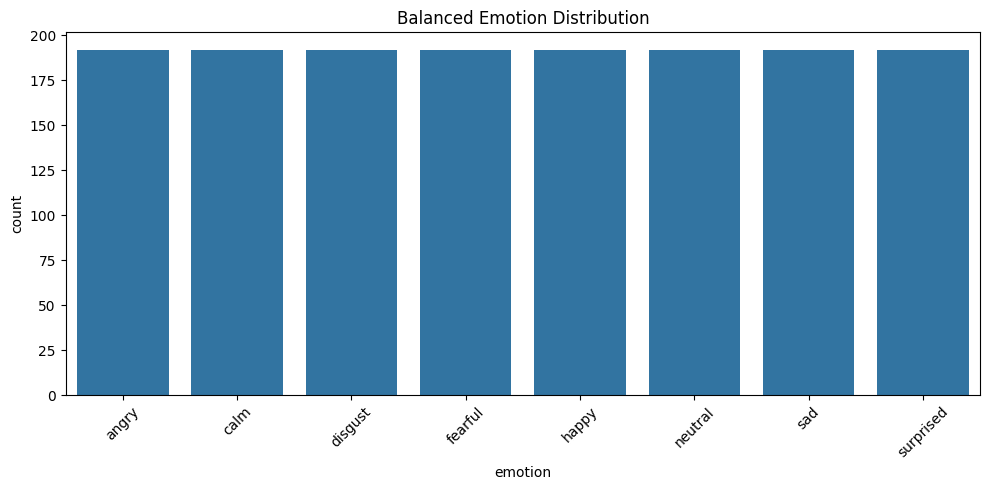

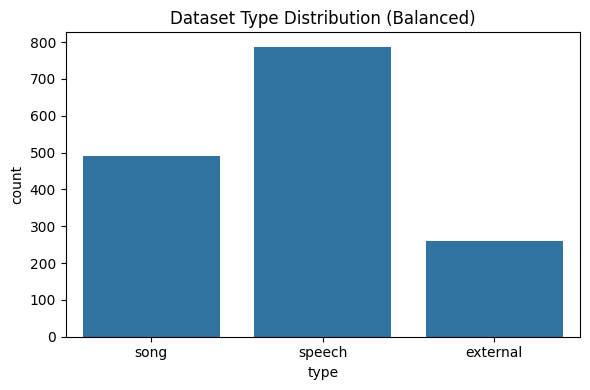

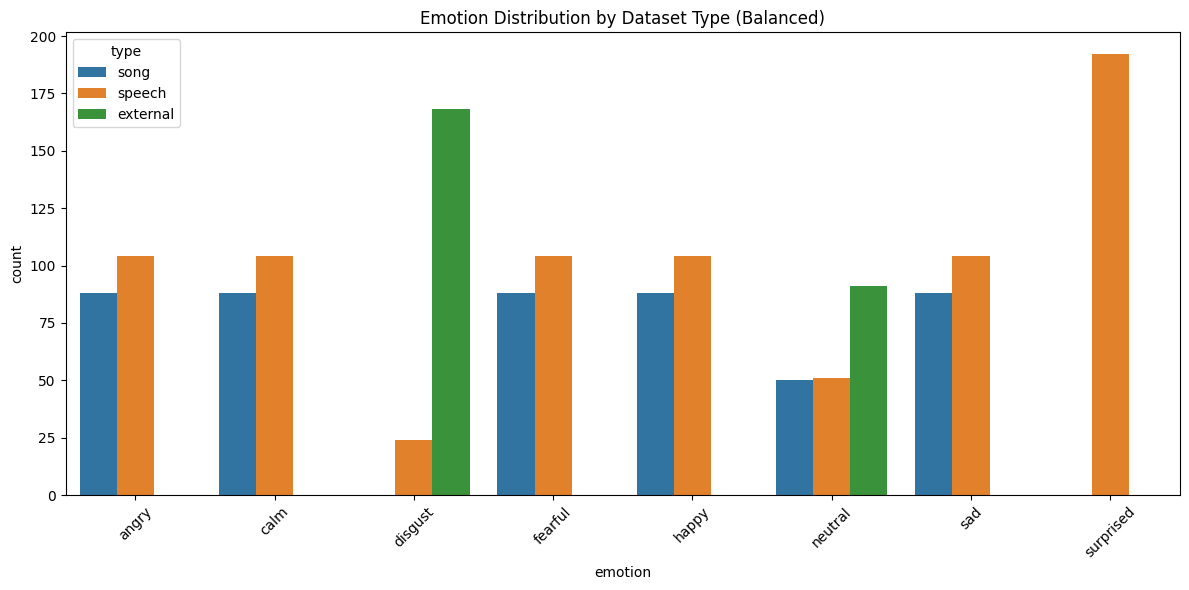


Total files: 3849


In [2]:
# ---------- STEP 1: Define dataset paths ----------
base_path = "/media/anshu/New Volume/Dataset"
speech_path = os.path.join(base_path, "Audio_Speech_Actors_01-24")
song_path   = os.path.join(base_path, "Audio_Song_Actors_01-24")
# Additional datasets for balancing
disgust_path    = os.path.join(base_path, "Disgust")
neutral_path    = os.path.join(base_path, "neutral-dataset")

print("Using dataset path:", base_path)

# Check paths exist
if not os.path.exists(base_path):
    raise FileNotFoundError(f"""
Dataset not found!

Expected path:
{base_path}

Please update the path in Dataset Selection section.
""")

# ---------- STEP 2: Load ALL wav files (Speech + Song) ----------
processed_files = []
for dataset_path in [speech_path, song_path]:
    for actor in os.listdir(dataset_path):
        actor_path = os.path.join(dataset_path, actor)
        if not os.path.isdir(actor_path):
            continue
        for file in os.listdir(actor_path):
            if file.endswith(".wav"):
                processed_files.append(os.path.join(actor_path, file))
print("RAVDESS files:", len(processed_files))

# ---------- STEP 3: Load Disgust dataset (TESS format: *_disgust.wav) ----------
disgust_files = []
for root, dirs, files in os.walk(disgust_path):
    for file in files:
        if file.endswith("_disgust.wav"):
            disgust_files.append(os.path.join(root, file))
print("Disgust files:", len(disgust_files))

# ---------- STEP 4: Load Neutral dataset (TESS format: *_neutral.wav) ----------
neutral_files = []
for root, dirs, files in os.walk(neutral_path):
    for file in files:
        if file.endswith("_neutral.wav"):
            neutral_files.append(os.path.join(root, file))
print("Neutral files:", len(neutral_files))

# ---------- STEP 5: Extract emotions + dataset type ----------
emotion_map_number = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

emotion_list = []
dataset_type_list = []

# RAVDESS files
for file in processed_files:
    file_name = os.path.basename(file)
    parts = file_name.split("-")
    if len(parts) < 3:
        continue
    emotion_code = parts[2]
    if emotion_code not in emotion_map_number:
        continue
    emotion = emotion_map_number[emotion_code]
    emotion_list.append(emotion)
    if "Speech" in file:
        dataset_type_list.append("speech")
    else:
        dataset_type_list.append("song")

# Disgust files (TESS format)
for file in disgust_files:
    emotion_list.append("disgust")
    dataset_type_list.append("external")

# Neutral files (TESS format)
for file in neutral_files:
    emotion_list.append("neutral")
    dataset_type_list.append("external")

# ---------- STEP 6: Create DataFrame ----------
df = pd.DataFrame({
    "emotion": emotion_list,
    "type": dataset_type_list
})

# ---------- STEP 7: Balance the dataset ----------
print("\nBefore balancing:")
print(df["emotion"].value_counts())

# Find the minimum count
min_count = df["emotion"].value_counts().min()

# Undersample each emotion to match the minimum
balanced_df = df.groupby("emotion").apply(
    lambda x: x.sample(n=min_count, random_state=42)
).reset_index(drop=True)

print("\nAfter balancing:")
print(balanced_df["emotion"].value_counts())

# ---------- STEP 8: Plot Emotion Distribution (Balanced) ----------
plt.figure(figsize=(10,5))
sns.countplot(data=balanced_df, x="emotion")
plt.title("Balanced Emotion Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------- STEP 9: Plot Dataset Balance ----------
plt.figure(figsize=(6,4))
sns.countplot(data=balanced_df, x="type")
plt.title("Dataset Type Distribution (Balanced)")
plt.tight_layout()
plt.show()

# ---------- STEP 10: Combined View ----------
plt.figure(figsize=(12,6))
sns.countplot(data=balanced_df, x="emotion", hue="type")
plt.title("Emotion Distribution by Dataset Type (Balanced)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Create file list for later use
wav_files = processed_files + disgust_files + neutral_files
files = wav_files
print("\nTotal files:", len(wav_files))

## 1.1 Dataset Emotion Distribution

# 1.2 Waveform Visualization

# 1.3 Spectrogram Visualization

Text(0.5, 1.0, 'Spectrogram')

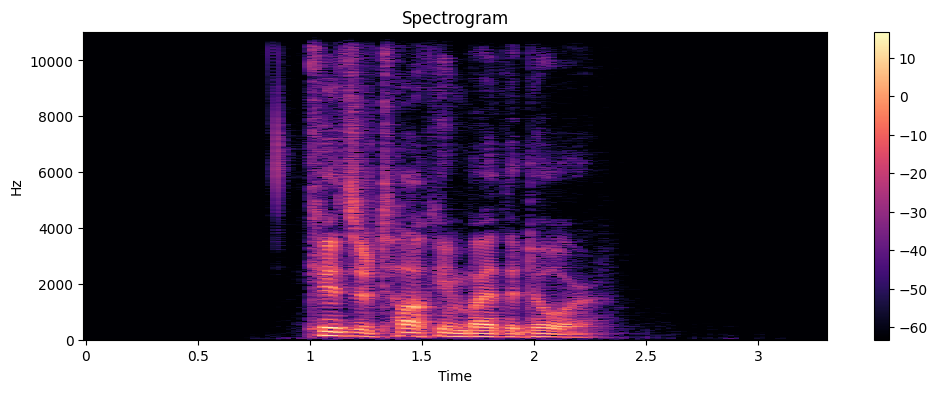

In [3]:
# Load audio for visualization
file = wav_files[0]
data, sr = librosa.load(file, sr=22050)

# Spectrogram
X = librosa.stft(data)
Xdb = librosa.amplitude_to_db(abs(X))

plt.figure(figsize=(12,4))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram")


# 1.4 MFCC Visualization

Text(0.5, 1.0, 'MFCC Features')

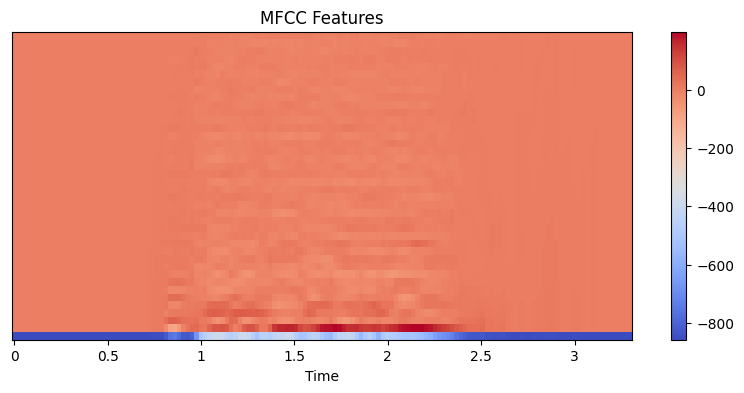

In [4]:
# Load audio for visualization
file = wav_files[0]
data, sr = librosa.load(file, sr=22050)

# MFCC
mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC Features")


# Add More Features (Better than MFCC Only)

Your notebook uses:

```
MFCC
Chroma
Mel
```

Research models use additional features:

| Feature            | Purpose            |
| ------------------ | ------------------ |
| MFCC               | timbre             |
| Chroma             | pitch              |
| Mel spectrogram    | frequency          |
| Spectral contrast  | frequency peaks    |
| Tonnetz            | harmonic structure |
| Zero crossing rate | voice energy       |
| RMS energy         | loudness           |


In [5]:
def extract_feature(data, sr, max_len=200):

    # Features
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T
    chroma = librosa.feature.chroma_stft(y=data, sr=sr).T
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=data, sr=sr, n_mels=64)
    ).T
    contrast = librosa.feature.spectral_contrast(y=data, sr=sr).T
    tonnetz = librosa.feature.tonnetz(
        y=librosa.effects.harmonic(data), sr=sr
    ).T
    zcr = librosa.feature.zero_crossing_rate(data).T
    rms = librosa.feature.rms(y=data).T

    # Match length
    min_len = min(len(mfcc), len(chroma), len(mel),
                  len(contrast), len(tonnetz), len(zcr), len(rms))

    mfcc = mfcc[:min_len]
    chroma = chroma[:min_len]
    mel = mel[:min_len]
    contrast = contrast[:min_len]
    tonnetz = tonnetz[:min_len]
    zcr = zcr[:min_len]
    rms = rms[:min_len]

    # Concat
    features = np.hstack([mfcc, chroma, mel, contrast, tonnetz, zcr, rms])

    # Feature scaling (per-feature normalization)
    features = (features - np.mean(features, axis=0)) / (np.std(features, axis=0) + 1e-6)

    # Pad / Truncate
    if features.shape[0] > max_len:
        features = features[:max_len]
    else:
        pad_width = max_len - features.shape[0]
        features = np.pad(features, ((0, pad_width), (0, 0)))

    return features

# 1.5 Feature Correlation Heatmap

In [6]:
data_directory = base_path
import glob
import os
import numpy as np
import librosa

sample_features = []

files = glob.glob(os.path.join(data_directory, "**/*.wav"), recursive=True)

print("Total files:", len(files))

for f in files[:50]:
    try:
        data, sr = librosa.load(f, sr=22050)
        feat = extract_feature(data, sr)

        # ✅ ensure correct shape
        if feat.shape[0] == 200:
            sample_features.append(feat)
        else:
            print("Skipped (shape issue):", f)

    except Exception as e:
        print("Skipped:", f, "| Error:", e)

# ✅ convert to numpy
sample_features = np.array(sample_features)

print("Sample shape:", sample_features.shape)

Total files: 17442
Sample shape: (50, 200, 131)


# Integrating Your Soft-Label Idea

Instead of:

```
neutral → [0,0,0,0,0,1,0,0]
```

Use:

```
neutral 0.7
angry 0.3

In [7]:
emotion_map = {
    'angry': 0,
    'calm': 1,
    'disgust': 2,
    'fearful': 3,
    'happy': 4,
    'neutral': 5,
    'sad': 6,
    'surprised': 7
}

def create_soft_label(primary, secondary=None, w1=0.7, w2=0.3):

    label = np.zeros(len(emotion_map))  # safer

    # ✅ always assign primary
    label[emotion_map[primary]] = w1 if secondary else 1.0

    # ✅ assign secondary only if exists
    if secondary:
        label[emotion_map[secondary]] = w2

    return label

# Automatically Generate Mixed Emotion Audio

```
Any sentence + Any word = mixed emotion audio
```

### Example:

```
neutral sentence + angry word = mixed emotion audio
```

# Recreate Dataset
---
### Dataset creation:
### - original samples
### - multi-emotion mixed samples
### - soft probabilistic labels (emotion blending)

In [8]:
np.random.seed(42)

In [9]:
# ===== PARALLEL DATA LOADING =====
from joblib import Parallel, delayed
import multiprocessing

num_cores = multiprocessing.cpu_count() - 1  # keep 1 core free

# Define process function for parallel execution
def process_file(file, emotion_map_number, emotion_map):
    local_X = []
    local_y = []
    
    try:
        data, sr = librosa.load(file, sr=22050)
    except:
        return local_X, local_y

    file_name = os.path.basename(file)
    parts = file_name.split("-")

    if len(parts) < 3:
        return local_X, local_y

    emotion_code = parts[2]
    
    if emotion_code not in emotion_map_number:
        return local_X, local_y

    primary_emotion = emotion_map_number[emotion_code]
    
    # Feature extraction
    feature = extract_feature(data, sr)
    
    # Ensure correct shape
    if feature.shape[0] != 200:
        return local_X, local_y
    
    local_X.append(feature)
    
    # One-hot label
    from tensorflow.keras.utils import to_categorical
    label = to_categorical(emotion_map[primary_emotion], num_classes=8)
    local_y.append(label)
    
    return local_X, local_y


# Execute in parallel (limit to 4 cores to avoid memory issues)
results = Parallel(n_jobs=min(4, num_cores), backend="loky")(
    delayed(process_file)(file, emotion_map_number, emotion_map)
    for file in files
)

# Merge results
X, y = [], []
for res_X, res_y in results:
    X.extend(res_X)
    y.extend(res_y)

# Convert to numpy
X = np.array(X)
y = np.array(y)

print("Dataset size:", X.shape)
print("Labels shape :", y.shape)

I0000 00:00:1775386647.951061   54314 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775386647.951490   54314 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775386647.990106   54317 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775386647.990581   54317 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775386647.991490   54314 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the follow

Dataset size: (2523, 200, 131)
Labels shape : (2523, 8)


# Saving the Features

In [10]:
import pickle
import os

output_dir = "cnn_lstm_output"
os.makedirs(output_dir, exist_ok=True)

# ✅ save emotion map
with open(os.path.join(output_dir, "emotion_map.pkl"), "wb") as f:
    pickle.dump(emotion_map, f)


# Data Split

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Convert soft labels to hard labels for stratification
y_hard = np.argmax(y, axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y_hard, random_state=42
)

# Normalize using training data only (per-feature normalization)
mean = np.mean(X_train, axis=(0,1), keepdims=True)
std  = np.std(X_train, axis=(0,1), keepdims=True)

X_train = (X_train - mean) / (std + 1e-6)
X_test  = (X_test - mean) / (std + 1e-6)

# Compute class weights for balanced training
y_train_hard = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_hard),
    y=y_train_hard
)
class_weight_dict = dict(zip(np.unique(y_train_hard), class_weights))
print("Class weights:", class_weight_dict)

print("Normalized:", X_train.shape, X_test.shape)
print("Train label shape:", y_train.shape)
print("Test label shape:", y_test.shape)

Class weights: {np.int64(0): np.float64(0.8163430420711975), np.int64(1): np.float64(0.8163430420711975), np.int64(2): np.float64(1.5864779874213837), np.int64(3): np.float64(0.8137096774193548), np.int64(4): np.float64(0.8243464052287581), np.int64(5): np.float64(1.6169871794871795), np.int64(6): np.float64(0.8189935064935064), np.int64(7): np.float64(1.5667701863354038)}
Normalized: (2018, 200, 131) (505, 200, 131)
Train label shape: (2018, 8)
Test label shape: (505, 8)


In [12]:
with open(os.path.join(output_dir, "normalization.pkl"), "wb") as f:
    pickle.dump({
        "mean": mean,
        "std": std
    }, f)


# Reshaping the Data

In [13]:
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

# CNN Architecture 

Our CNN is very shallow. We need:

* BatchNormalization
* deeper convolution
* regularization

---

## Improved CNN

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,              # 🔥 slightly higher for deep model
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,               # 🔥 smoother reduction
    patience=7,               # 🔥 avoid too early drop
    min_lr=1e-6,
    verbose=1
)

# Model checkpoint

In [15]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    os.path.join(output_dir, "best_model.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [16]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Input shape will be determined at runtime based on feature extraction
# Using a flexible model that can adapt

input_layer = Input(shape=(200, 131))  # MFCC(40) + Chroma(12) + Mel(64) + Contrast(7) + Tonnetz(6) + ZCR(1) + RMS(1)

# CNN BLOCK 1
x = Conv1D(128, 5, padding='same', activation='relu')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.2)(x)

# CNN BLOCK 2
x = Conv1D(256, 3, padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.2)(x)

# CNN BLOCK 3
x = Conv1D(256, 3, padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.3)(x)

# LSTM
x = Bidirectional(LSTM(128, return_sequences=True))(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64))(x)

# Dense
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

x = Dense(64, activation='relu')(x)

output = Dense(8, activation='softmax')(x)  # 8 classes (keep all for now)

model = Model(inputs=input_layer, outputs=output)

# Compile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 131)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 200, 128)       │        83,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 25, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 25, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 965,832 (3.68 MB)

 Trainable params: 964,552 (3.68 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [17]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.00015)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

# Fix shape - remove unnecessary dimension if present
if len(X_train.shape) > 3:
    X_train = np.squeeze(X_train)
    X_test = np.squeeze(X_test)

print("Training data shape:", X_train.shape)

# Set device policy for GPU
import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.config.set_soft_device_placement(True)

# Train with class weights for balanced learning
history = model.fit(
    X_train,
    y_train,
    epochs=80,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 131)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 200, 128)       │        83,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 25, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 25, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 965,832 (3.68 MB)

 Trainable params: 964,552 (3.68 MB)

 Non-trainable params: 1,280 (5.00 KB)

Training data shape: (2018, 200, 131)
Epoch 1/80
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1764 - loss: 2.0303
Epoch 1: val_accuracy improved from None to 0.19604, saving model to cnn_lstm_output/best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.2047 - loss: 2.0450 - val_accuracy: 0.1960 - val_loss: 2.0335 - learning_rate: 1.5000e-04
Epoch 2/80
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2424 - loss: 1.9639
Epoch 2: val_accuracy improved from 0.19604 to 0.26931, saving model to cnn_lstm_output/best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.2374 - loss: 1.9560 - val_accuracy: 0.2693 - val_loss: 1.9421 - learning_rate: 1.5000e-04
Epoch 3/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3139 - loss: 1.8665
Epoch 3: val_accuracy improved from 0.26931 to 0.32475, saving model to cnn_lstm_output/best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.3295 - loss: 1.8166 - val_accuracy: 0.3248 - val_loss

# Model Save

In [18]:
model.save(os.path.join(output_dir, "final_model_cnn_lstm.keras"))


# Evaluation Matrics

In [19]:
from sklearn.metrics import classification_report, accuracy_score

# Convert soft labels → hard labels
y_true = np.argmax(y_test, axis=1)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_true, y_pred_classes))

# Full report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=list(emotion_map.keys())))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
Accuracy: 0.6336633663366337

Classification Report:

              precision    recall  f1-score   support

       angry       0.66      0.84      0.74        77
        calm       0.73      0.79      0.76        78
     disgust       0.79      0.57      0.67        40
     fearful       0.87      0.26      0.40        78
       happy       0.91      0.51      0.66        76
     neutral       0.37      0.97      0.54        39
         sad       0.69      0.49      0.58        77
   surprised       0.51      0.88      0.64        40

    accuracy                           0.63       505
   macro avg       0.69      0.67      0.62       505
weighted avg       0.72      0.63      0.62       505



# confusion matrix visual

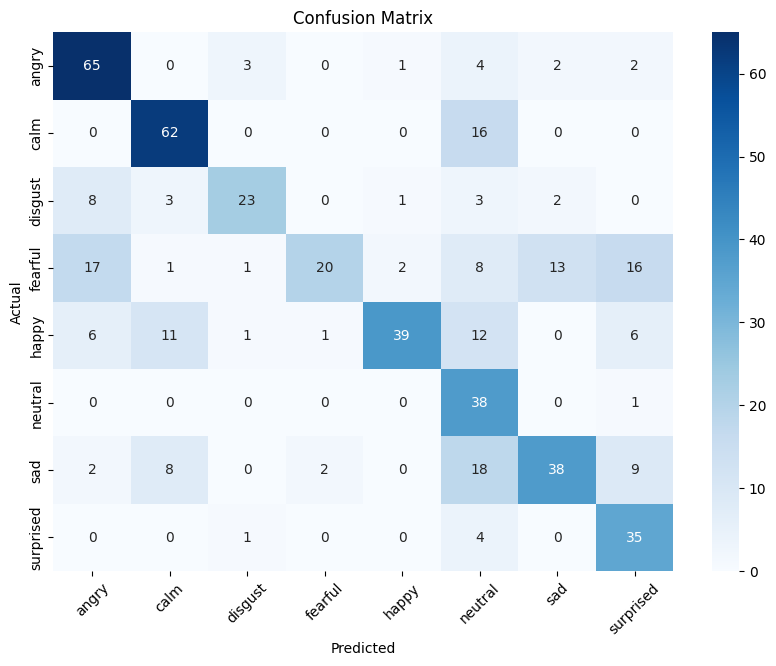

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

labels = list(emotion_map.keys())
plt.xticks(np.arange(len(labels))+0.5, labels, rotation=45)
plt.yticks(np.arange(len(labels))+0.5, labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
import numpy as np

cm = confusion_matrix(y_true, y_pred_classes)

TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (FP + FN + TP)

TPR = TP / (TP + FN)   # Recall
FPR = FP / (FP + TN)
TNR = TN / (TN + FP)   # Specificity

print("\nTPR (Recall):", TPR)
print("FPR:", FPR)
print("TNR (Specificity):", TNR)


TPR (Recall): [0.84415584 0.79487179 0.575      0.25641026 0.51315789 0.97435897
 0.49350649 0.875     ]
FPR: [0.0771028  0.05386417 0.01290323 0.00702576 0.00932401 0.13948498
 0.03971963 0.07311828]
TNR (Specificity): [0.9228972  0.94613583 0.98709677 0.99297424 0.99067599 0.86051502
 0.96028037 0.92688172]


In [22]:
print("\nAverage Metrics:")

print("Mean TPR (Recall):", np.mean(TPR))
print("Mean FPR:", np.mean(FPR))
print("Mean TNR:", np.mean(TNR))


Average Metrics:
Mean TPR (Recall): 0.6658076572550256
Mean FPR: 0.05156785661125709
Mean TNR: 0.9484321433887428


In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true, y_pred_classes, average='weighted'))
print("Recall:", recall_score(y_true, y_pred_classes, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred_classes, average='weighted'))

Precision: 0.7214340757449704
Recall: 0.6336633663366337
F1 Score: 0.6233761411947122


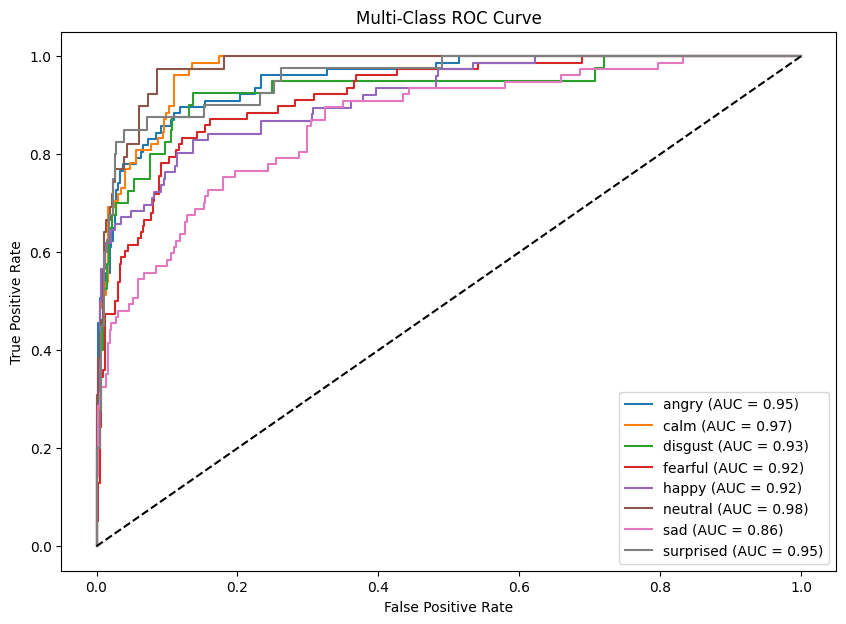

Average AUC: 0.9355456903906718


In [24]:
n_classes = 8

# Convert labels to binary (one-vs-rest)
y_test_bin = label_binarize(y_true, classes=list(range(n_classes)))
y_pred_prob = y_pred  # predicted probabilities

# Compute ROC and AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10,7))

labels = list(emotion_map.keys())

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

# Optional: average AUC
print("Average AUC:", np.mean(list(roc_auc.values())))

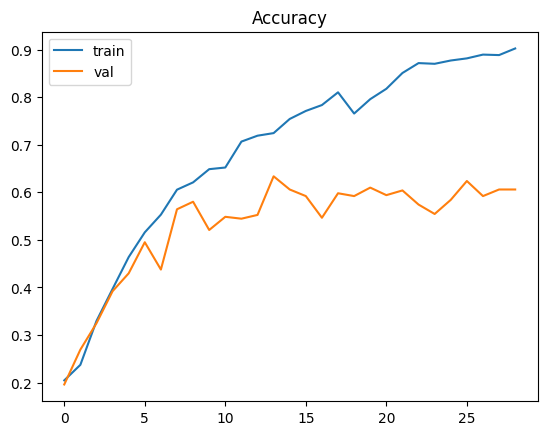

In [25]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["train", "val"])
plt.show()

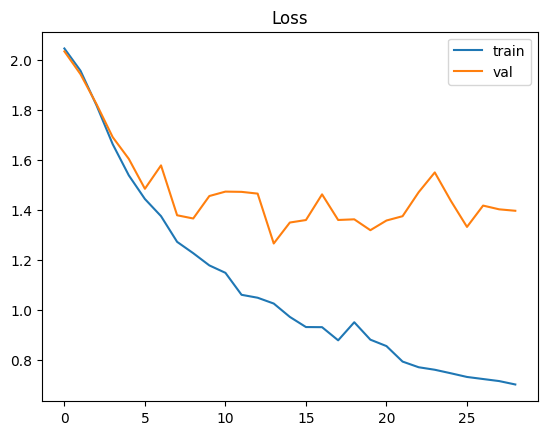

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["train", "val"])
plt.show()

In [27]:
from tensorflow.keras.models import load_model

loaded_model = load_model(os.path.join(output_dir, "final_model_cnn_lstm.keras"))
loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded model accuracy:", acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6337 - loss: 1.2644
Loaded model accuracy: 0.6336633563041687


### Save new audio:

# Real-Time Emotion Detection

Record audio:

In [28]:
import sounddevice as sd

def record_audio(duration=3, sr=22050, device=None):

    print("Speak now...")

    audio = sd.rec(int(duration * sr),
                   samplerate=sr,
                   channels=1,
                   device=device)

    sd.wait()

    return audio.flatten()

import librosa
import glob
import os
import librosa.display
import soundfile as sf
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import platform
import seaborn as sns
import pandas as pd

def extract_feature(data, sr, max_len=200):

    # Features
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T
    chroma = librosa.feature.chroma_stft(y=data, sr=sr).T
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=data, sr=sr, n_mels=64)
    ).T
    contrast = librosa.feature.spectral_contrast(y=data, sr=sr).T
    tonnetz = librosa.feature.tonnetz(
        y=librosa.effects.harmonic(data), sr=sr
    ).T
    zcr = librosa.feature.zero_crossing_rate(data).T
    rms = librosa.feature.rms(y=data).T

    # Match length
    min_len = min(len(mfcc), len(chroma), len(mel),
                  len(contrast), len(tonnetz), len(zcr), len(rms))

    mfcc = mfcc[:min_len]
    chroma = chroma[:min_len]
    mel = mel[:min_len]
    contrast = contrast[:min_len]
    tonnetz = tonnetz[:min_len]
    zcr = zcr[:min_len]
    rms = rms[:min_len]

    # Concat
    features = np.hstack([mfcc, chroma, mel, contrast, tonnetz, zcr, rms])

    # Feature scaling (per-feature normalization)
    features = (features - np.mean(features, axis=0)) / (np.std(features, axis=0) + 1e-6)

    # Pad / Truncate
    if features.shape[0] > max_len:
        features = features[:max_len]
    else:
        pad_width = max_len - features.shape[0]
        features = np.pad(features, ((0, pad_width), (0, 0)))

    return features

from tensorflow.keras.models import load_model
loaded_model = load_model("/home/anshu/EmotionDetection-from-voice/Ravdees-Training/cnn_lstm_output/final_model_cnn_lstm.keras")

# Predict emotion:

In [29]:
import pickle

# Load normalization values
with open(os.path.join(output_dir, "normalization.pkl"), "rb") as f:
    norm = pickle.load(f)
    mean = norm["mean"]
    std = norm["std"]

# Load emotion map
with open("/home/anshu/EmotionDetection-from-voice/Ravdees-Training/cnn_lstm_output/emotion_map.pkl", "rb") as f:
    emotion_map = pickle.load(f)

# Record audio
audio = record_audio()

# Extract features
feature = extract_feature(audio, 22050)

# Normalize using saved mean/std
feature = (feature - mean) / (std + 1e-6)

# Ensure 2D shape (200, 195) - reshape if needed
if len(feature.shape) > 2:
    feature = feature.reshape(feature.shape[-2:])

# Reshape to match model input (batch, 200, 195)
feature = feature.reshape(1, 200, 131)

# Predict
prediction = loaded_model.predict(feature)

# Map back to emotion
inv_map = {v:k for k,v in emotion_map.items()}
emotion = inv_map[np.argmax(prediction)]

print("Emotion:", emotion)


Speak now...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
Emotion: fearful


In [42]:
import random
import librosa
import numpy as np

# ===== RANDOM FILE =====
file_list = wav_files  # Use the wav_files from earlier
random_file = random.choice(file_list)
print("Testing file:", random_file)

# ===== LOAD AUDIO =====
audio, sr = librosa.load(random_file, sr=22050)

# ===== GET TRUE LABEL =====
file_name = os.path.basename(random_file)
parts = file_name.split("-")

if len(parts) >= 3:
    emotion_code = parts[2]
    true_emotion = emotion_map_number.get(emotion_code, "unknown")
else:
    true_emotion = "unknown"

print("True Emotion:", true_emotion)

# ===== FEATURE EXTRACTION (MATCH TRAINING) =====
feature = extract_feature(audio, sr)

# ===== NORMALIZATION =====
feature = (feature - mean) / (std + 1e-6)

# Ensure 2D shape and add batch dimension
if len(feature.shape) > 2:
    feature = feature.reshape(feature.shape[-2:])
feature = feature.reshape(1, 200, 131)

# ===== PREDICTION =====
prediction = loaded_model.predict(feature)

# ===== MAP BACK =====
inv_map = {v:k for k,v in emotion_map.items()}
predicted_emotion = inv_map[np.argmax(prediction)]

print("\nPredicted Emotion:", predicted_emotion)

# ===== FULL PROBABILITIES =====
print("\nPrediction probabilities:")
for i, prob in enumerate(prediction[0]):
    print(f"{inv_map[i]}: {prob:.4f}")

Testing file: /media/anshu/New Volume/Dataset/Audio_Speech_Actors_01-24/Actor_07/03-01-08-01-02-02-07.wav
True Emotion: surprised
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

Predicted Emotion: surprised

Prediction probabilities:
angry: 0.0258
calm: 0.0056
disgust: 0.0214
fearful: 0.0427
happy: 0.0709
neutral: 0.0298
sad: 0.0158
surprised: 0.7881
